In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio
from scipy.signal import welch

In [2]:
sub_50 = sio.loadmat('s50.mat')
sub_50['eeg']['imagery_left'][0][0][0][0]

np.float32(-620387.5)

In [3]:
sub_50['eeg']['imagery_left'][0,0].shape

(68, 358400)

In [14]:
eeg = sub_50['eeg']['imagery_left'][0,0][:64, :]
eeg.shape[0]

64

In [37]:
#sampling freq
fs = 512 #thus Nyquist freq = 256

# 68 channels x samples
data = sub_50['eeg']['imagery_left'][0][0]

# only EEG channels (1st 64 channels)
eeg = data[:64, :]

# PSD for all channels
psd_all = []

for ch in range(eeg.shape[0]):
    freqs, psd = welch(eeg[ch, :], fs=fs, window='hann', nperseg=1024, noverlap=512, detrend='constant')
    psd_all.append(psd)

psd_all = np.array(psd_all)

print(freqs[0],freqs[-1], psd_all.shape)


0.0 256.0 (64, 513)


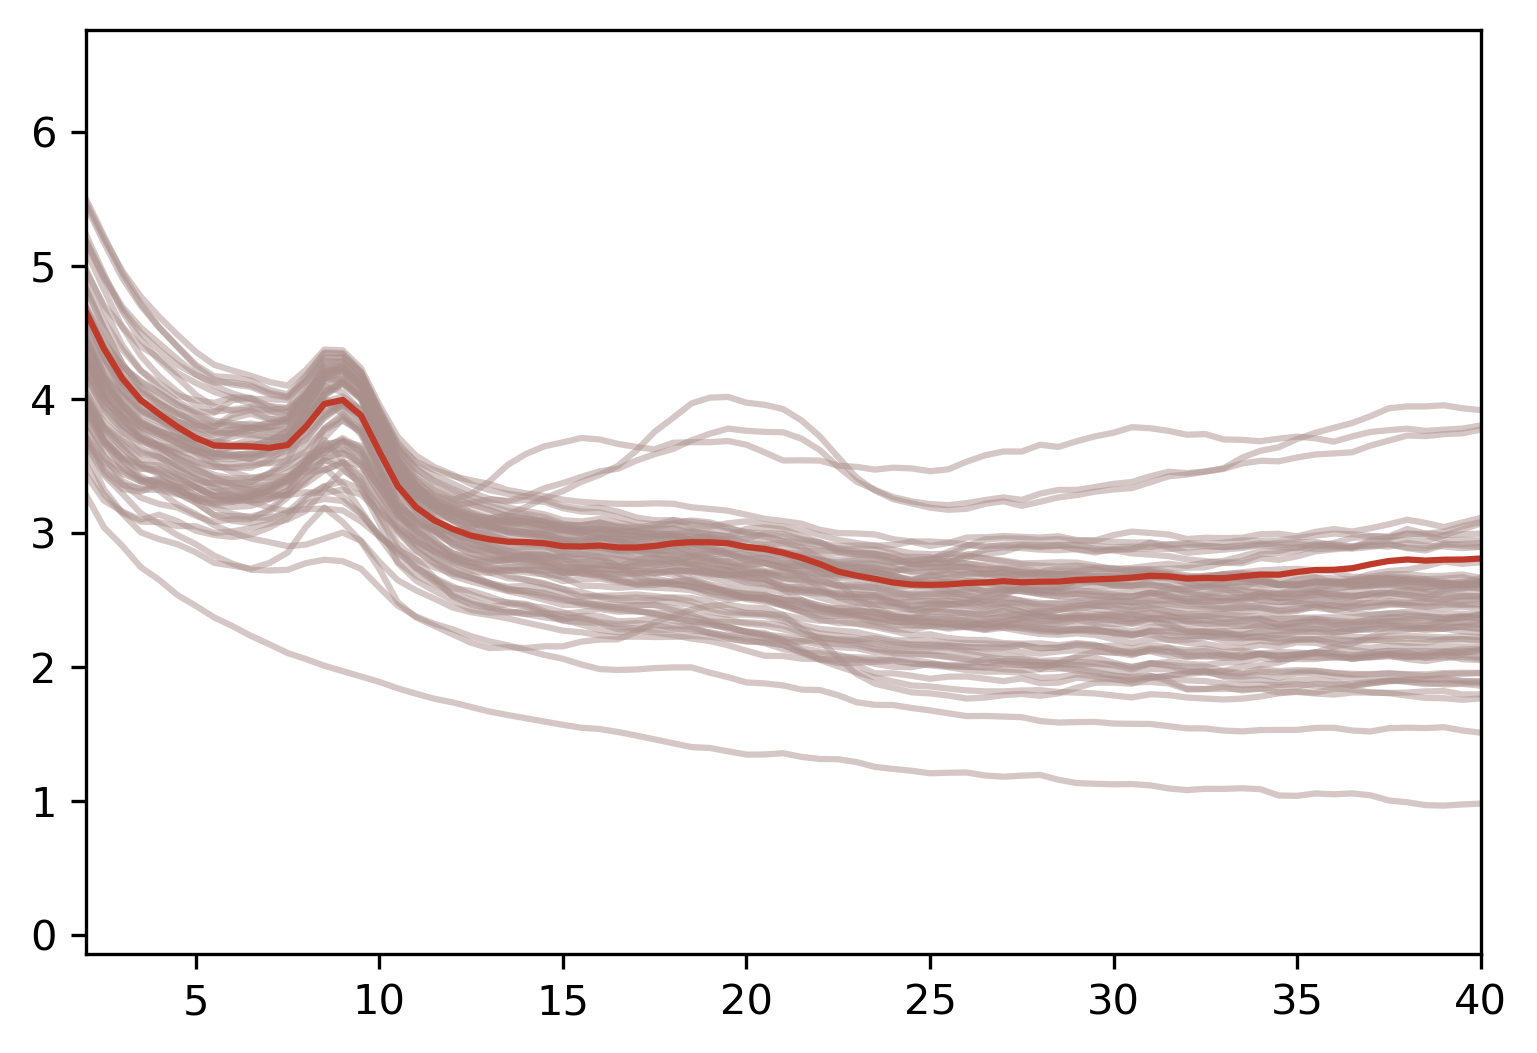

In [41]:
# mean psd across channels
col = "#AA908D"

mean_psd = np.mean(psd_all, axis=0)

plt.figure(figsize=(6, 4), dpi=300)
for ch in range(64):
    plt.plot(freqs, np.log10(psd_all[ch, :]), alpha = 0.5, color= col)

plt.plot(freqs, np.log10(mean_psd), color= "#BE3A2B")
plt.xlim([2, 40])
plt.show()

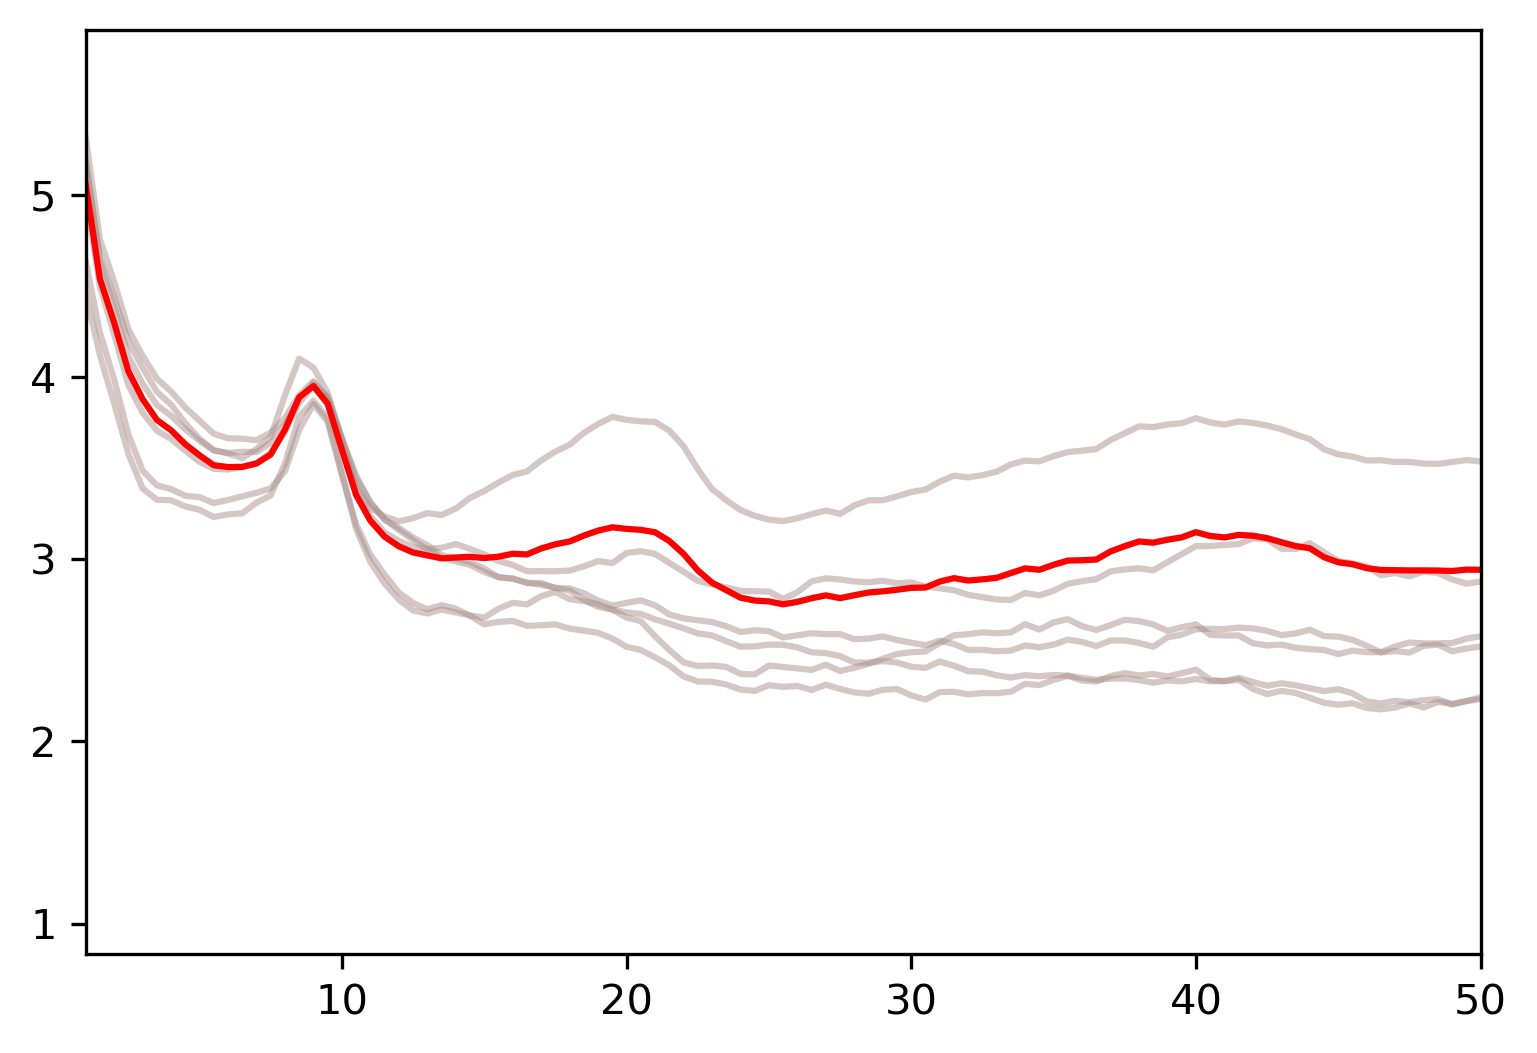

In [7]:
motor_channels = [14, 13, 12, 48, 49, 50]

col = "#AA908D"

mean_motor = np.mean(psd_all[motor_channels, :], axis=0)

plt.figure(figsize=(6, 4), dpi=300)
for ch in motor_channels:
    plt.plot(freqs, np.log10(psd_all[ch, :]), alpha=0.5, color = col)

plt.plot(freqs, np.log10(mean_motor), color = 'red')
plt.xlim([1, 50])
plt.show()

### Apply Bandpass filtering

In [42]:
from scipy.signal import butter, filtfilt

In [43]:
#function for bandpass
def bandpass(data, low, high, fs, order=4):
    nyq = fs/2
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, data)

In [44]:
#Filter out stuffs in time-domain
eeg_filterd = np.zeros(eeg.shape)

for ch in range(64):
    eeg_filterd[ch] = bandpass(eeg[ch], low=0.5, high=55, fs=600)

eeg_filterd.shape

(64, 358400)

In [45]:
# Now compute PSD
psd_all = []

for ch in range(64):
    freqs, psd = welch(eeg_filterd[ch, :], window='hann', fs=600, nperseg=2048, noverlap=0.5*2048, detrend='constant')
    psd_all.append(psd)

psd_all = np.array(psd_all)
print(freqs.shape, psd_all.shape)

(1025,) (64, 1025)


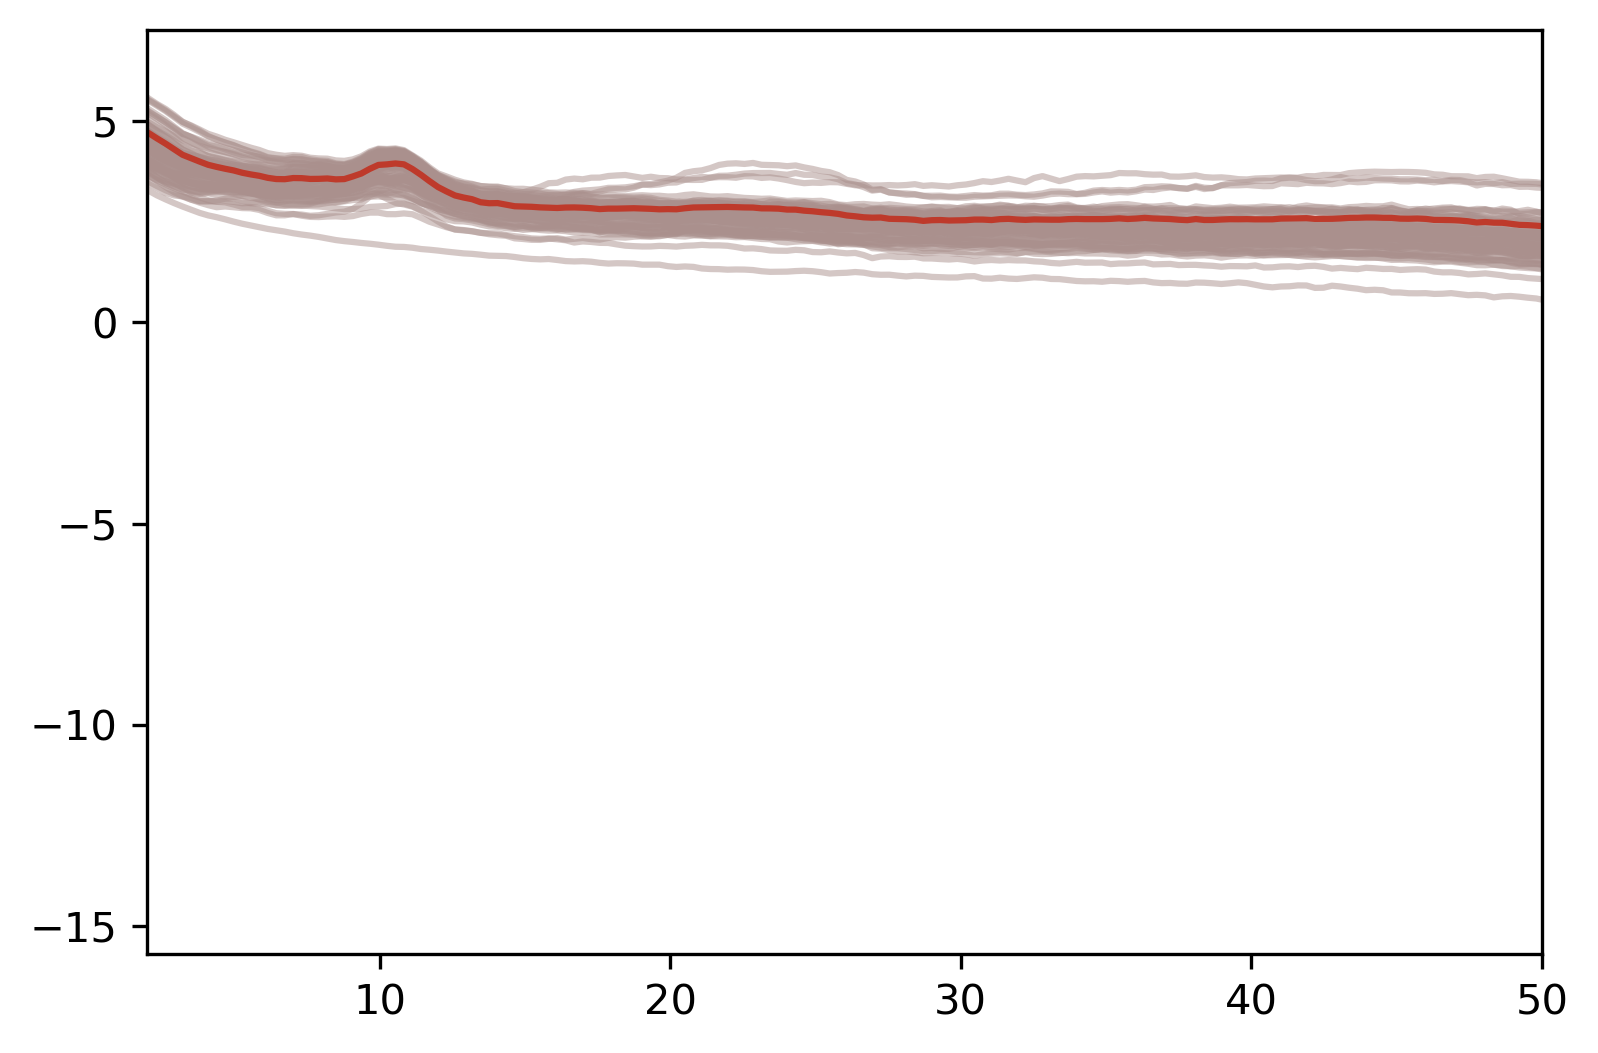

In [48]:
# mean psd across channels
col = "#AA908D"

mean_psd = np.mean(psd_all, axis=0)

plt.figure(figsize=(6, 4), dpi=300)
for ch in range(64):
    plt.plot(freqs, np.log10(psd_all[ch, :]), alpha = 0.5, color= col)

plt.plot(freqs, np.log10(mean_psd), color= "#BE3A2B")
plt.xlim([2, 50])
plt.show()

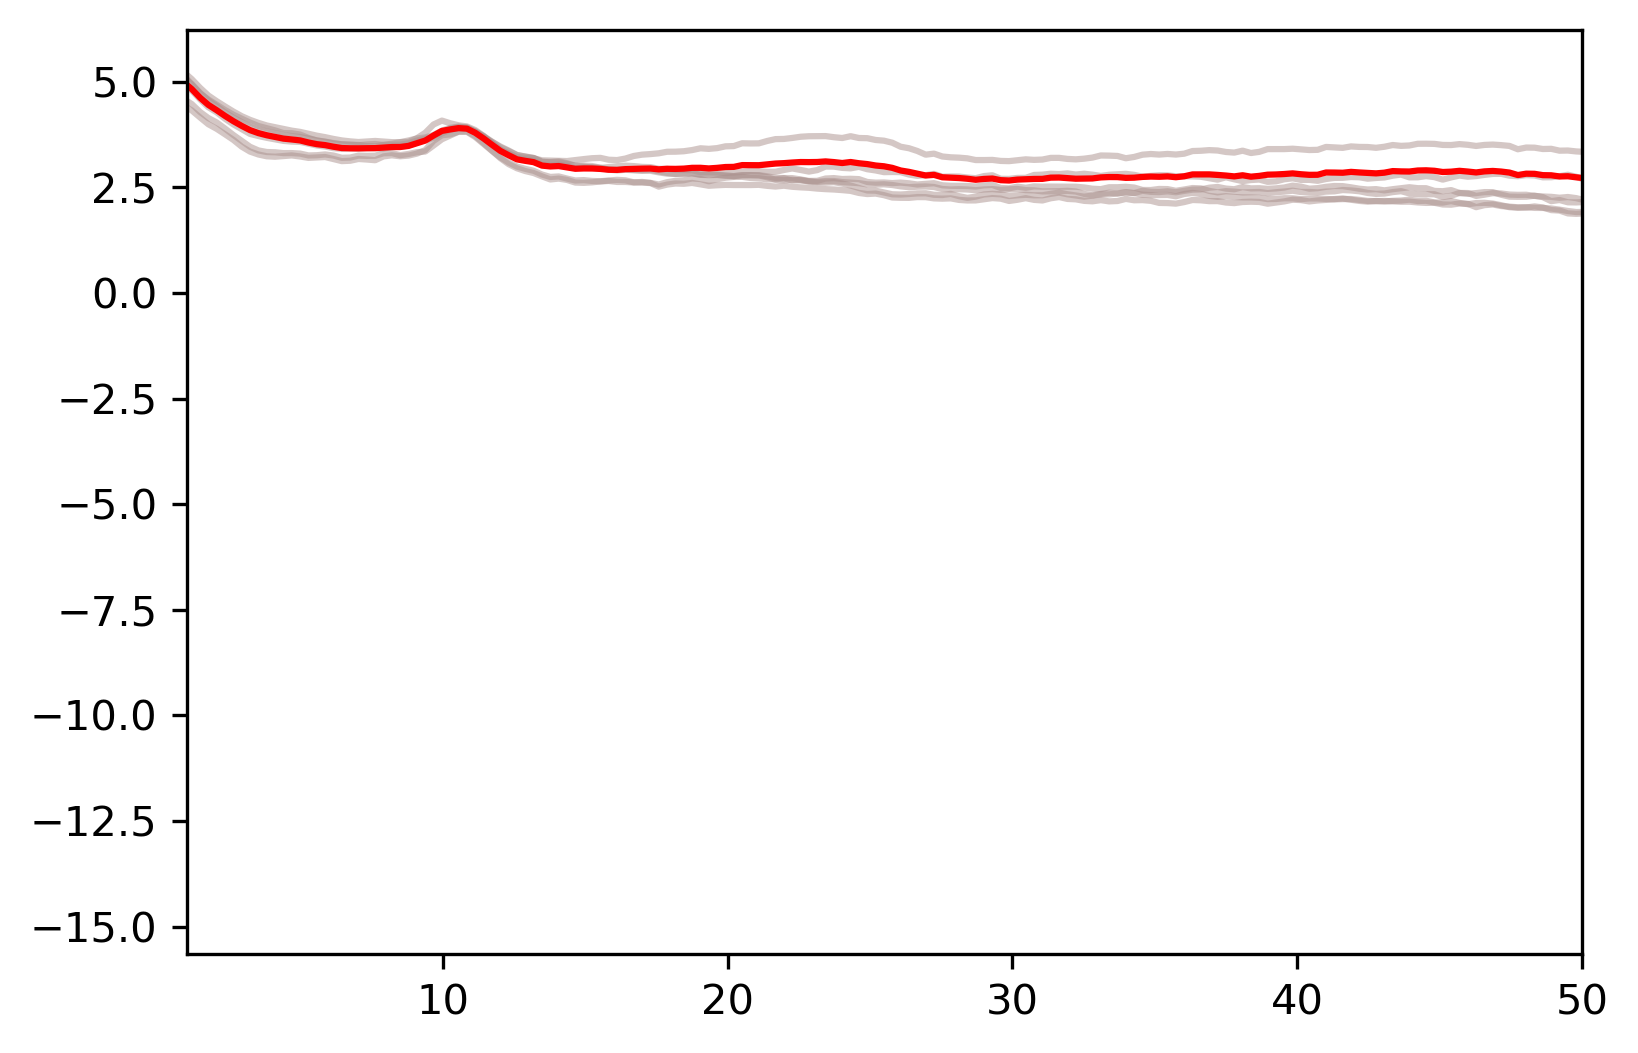

In [49]:
motor_channels = [14, 13, 12, 48, 49, 50]

col = "#AA908D"

mean_motor = np.mean(psd_all[motor_channels, :], axis=0)

plt.figure(figsize=(6, 4), dpi=300)
for ch in motor_channels:
    plt.plot(freqs, np.log10(psd_all[ch, :]), alpha=0.5, color = col)

plt.plot(freqs, np.log10(mean_motor), color = 'red')
plt.xlim([1, 50])
plt.show()